In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps Shape:", apps_df.shape)
print("Reviews Shape:", reviews_df.shape)

Apps Shape: (10841, 13)
Reviews Shape: (64295, 5)


In [4]:
apps_df.shape

(10841, 13)

In [5]:
print("Apps Dataset Columns")
print(apps_df.columns)

print("\nReviews Dataset Columns")
print(reviews_df.columns)

Apps Dataset Columns
Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

Reviews Dataset Columns
Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


In [6]:
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [8]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [9]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


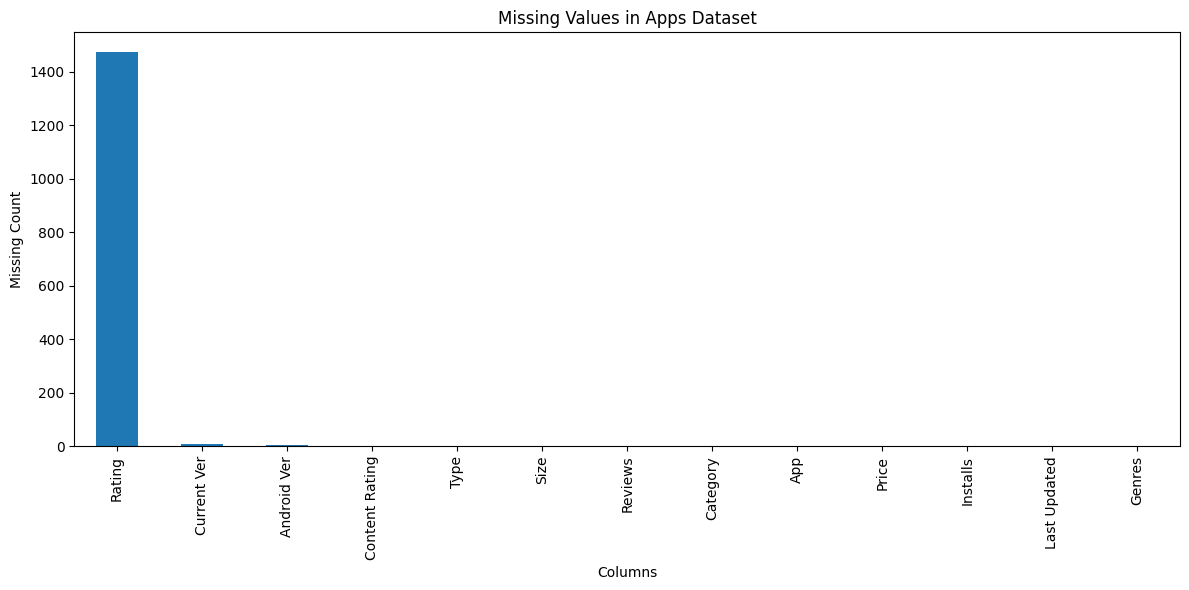

In [10]:
import matplotlib.pyplot as plt

missing = apps_df.isnull().sum()

plt.figure(figsize=(12,6))
missing.sort_values(ascending=False).plot(kind='bar')

plt.title("Missing Values in Apps Dataset")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

plt.tight_layout()

# Save image
plt.savefig(
    "missing_values_apps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
apps_clean = apps_df.copy()
reviews_clean = reviews_df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [12]:
print("Duplicate Apps:", apps_clean["App"].duplicated().sum())

Duplicate Apps: 1181


In [13]:
apps_clean[apps_clean["App"].duplicated(keep=False)]\
.sort_values("App")\
.head(20)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3.8M,"500,000+",Free,0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2322,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26M,"1,000,000+",Free,0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up
2385,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
2256,2017 EMRA Antibiotic Guide,MEDICAL,4.4,12,3.8M,"1,000+",Paid,$16.99,Everyone,Medical,"January 27, 2017",1.0.5,4.0.3 and up
1337,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15M,"100,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up
3083,365Scores - Live Scores,SPORTS,4.6,666521,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up
5415,365Scores - Live Scores,SPORTS,4.6,666246,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up


In [14]:
apps_clean = apps_clean.drop_duplicates(subset="App")

print("New Shape:", apps_clean.shape)

New Shape: (9660, 13)


In [15]:
apps_clean["Reviews"] = pd.to_numeric(
    apps_clean["Reviews"],
    errors="coerce"
)

print(apps_clean["Reviews"].dtype)

float64


In [16]:
apps_clean.to_csv(
    "apps_clean_v1.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [17]:
apps_clean["Installs"] = (
    apps_clean["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_clean["Installs"] = pd.to_numeric(
    apps_clean["Installs"],
    errors="coerce"
)

print(apps_clean["Installs"].dtype)

apps_clean["Installs"].head()

float64


0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
Name: Installs, dtype: float64

In [18]:
apps_clean["Price"] = (
    apps_clean["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)

apps_clean["Price"] = pd.to_numeric(
    apps_clean["Price"],
    errors="coerce"
)

print(apps_clean["Price"].dtype)

apps_clean["Price"].head()

float64


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [19]:
print(
    "Missing Ratings:",
    apps_clean["Rating"].isnull().sum()
)

Missing Ratings: 1463


In [20]:
median_rating = apps_clean["Rating"].median()

apps_clean["Rating"] = apps_clean["Rating"].fillna(
    median_rating
)

print(
    apps_clean["Rating"].isnull().sum()
)

0


In [21]:
print("\nShape")
print(apps_clean.shape)

print("\nMissing Values")
print(apps_clean.isnull().sum())

print("\nData Types")
print(apps_clean.dtypes)


Shape
(9660, 13)

Missing Values
App               0
Category          0
Rating            0
Reviews           1
Size              0
Installs          1
Type              1
Price             1
Content Rating    1
Genres            0
Last Updated      0
Current Ver       8
Android Ver       3
dtype: int64

Data Types
App                object
Category           object
Rating            float64
Reviews           float64
Size               object
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object


In [22]:
apps_clean.to_csv(
    "apps_clean_v2.csv",
    index=False
)

print("apps_clean_v2.csv Saved")

apps_clean_v2.csv Saved


In [23]:
apps_clean["Size"].sample(20)

6399                    12M
2079                    27M
1480                   9.2M
3234     Varies with device
5864                    73M
5586                   6.2M
10422                  7.8M
8605                   7.5M
9564                    73M
5088                   4.6M
7394                    14M
6266                    25M
7591                    58M
1557                    21M
2913     Varies with device
7984                    16M
4073                    89M
587                     38M
3184                   3.1M
9270                    35M
Name: Size, dtype: object

In [24]:
def clean_size(size):

    if size == "Varies with device":
        return None

    size = str(size)

    if "M" in size:
        return float(size.replace("M", "")) * 1024

    elif "k" in size:
        return float(size.replace("k", ""))

    else:
        return None


apps_clean["Size_KB"] = apps_clean["Size"].apply(clean_size)

apps_clean["Size_KB"].head()

0    19456.0
1    14336.0
2     8908.8
3    25600.0
4     2867.2
Name: Size_KB, dtype: float64

In [25]:
print(
    apps_clean["Size_KB"].isnull().sum()
)

1228


In [26]:
median_size = apps_clean["Size_KB"].median()

apps_clean["Size_KB"] = apps_clean["Size_KB"].fillna(
    median_size
)

print(
    apps_clean["Size_KB"].isnull().sum()
)

0


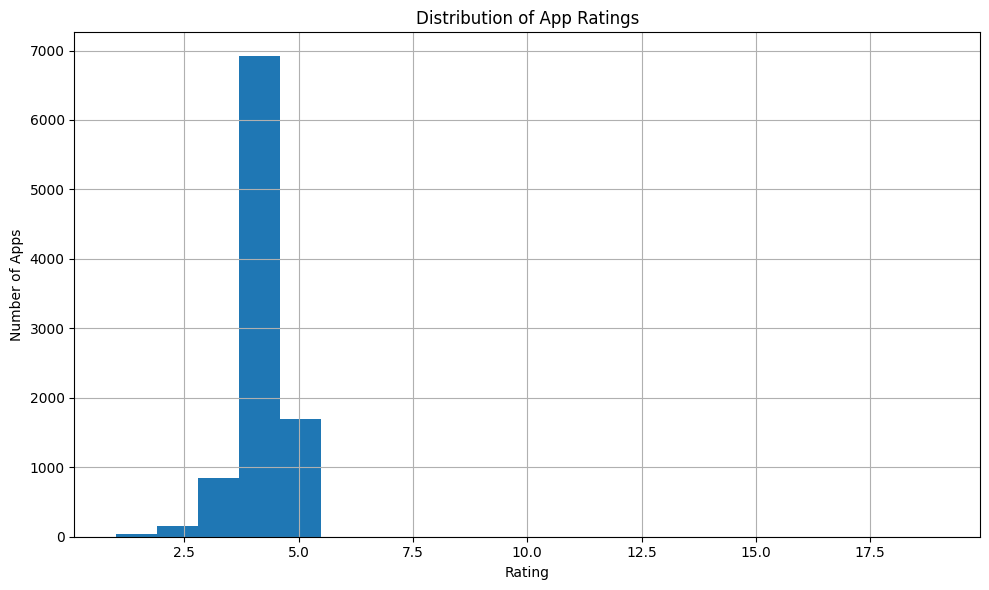

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

apps_clean["Rating"].hist(
    bins=20
)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.tight_layout()

plt.savefig(
    "rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
apps_clean[
    apps_clean.isnull().any(axis=1)
]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_KB
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55.0,2.7M,5000.0,Free,0.00,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up,2764.8
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145.0,11k,1000000.0,Free,0.00,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up,11.0
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230.0,11M,1000.0,Paid,1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN,11264.0
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189.0,2.1M,10000.0,Free,0.00,Everyone,Personalization,"March 27, 2018",1.1,NaN,2150.4
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010.0,8.7M,500000.0,Free,0.00,Everyone,Tools,"May 10, 2017",NaN,4.0 and up,8908.8
6803,BT Master,FAMILY,4.3,0.0,222k,100.0,Free,0.00,Everyone,Education,"November 6, 2016",NaN,1.6 and up,222.0
7333,Dots puzzle,FAMILY,4.0,179.0,14M,50000.0,Paid,0.99,Everyone,Puzzle,"April 18, 2018",NaN,4.0 and up,14336.0
7407,Calculate My IQ,FAMILY,4.3,44.0,7.2M,10000.0,Free,0.00,Everyone,Entertainment,"April 3, 2017",NaN,2.3 and up,7372.8
7730,UFO-CQ,TOOLS,4.3,1.0,237k,10.0,Paid,0.99,Everyone,Tools,"July 4, 2016",NaN,2.0 and up,237.0
9148,Command & Conquer: Rivals,FAMILY,4.3,0.0,Varies with device,0.0,NaN,0.00,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device,12288.0


In [29]:
apps_clean[
    apps_clean.isnull().any(axis=1)
].head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_KB
15,Learn To Draw Kawaii Characters,ART_AND_DESIGN,3.2,55.0,2.7M,5000.0,Free,0.00,Everyone,Art & Design,"June 6, 2018",NaN,4.2 and up,2764.8
1553,Market Update Helper,LIBRARIES_AND_DEMO,4.1,20145.0,11k,1000000.0,Free,0.00,Everyone,Libraries & Demo,"February 12, 2013",NaN,1.5 and up,11.0
4453,[substratum] Vacuum: P,PERSONALIZATION,4.4,230.0,11M,1000.0,Paid,1.49,Everyone,Personalization,"July 20, 2018",4.4,NaN,11264.0
4490,Pi Dark [substratum],PERSONALIZATION,4.5,189.0,2.1M,10000.0,Free,0.00,Everyone,Personalization,"March 27, 2018",1.1,NaN,2150.4
6322,Virtual DJ Sound Mixer,TOOLS,4.2,4010.0,8.7M,500000.0,Free,0.00,Everyone,Tools,"May 10, 2017",NaN,4.0 and up,8908.8


In [30]:
print("Before:", apps_clean.shape)

apps_clean = apps_clean.dropna()

print("After:", apps_clean.shape)

Before: (9660, 14)
After: (9648, 14)


In [31]:
apps_clean.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
Size_KB           0
dtype: int64

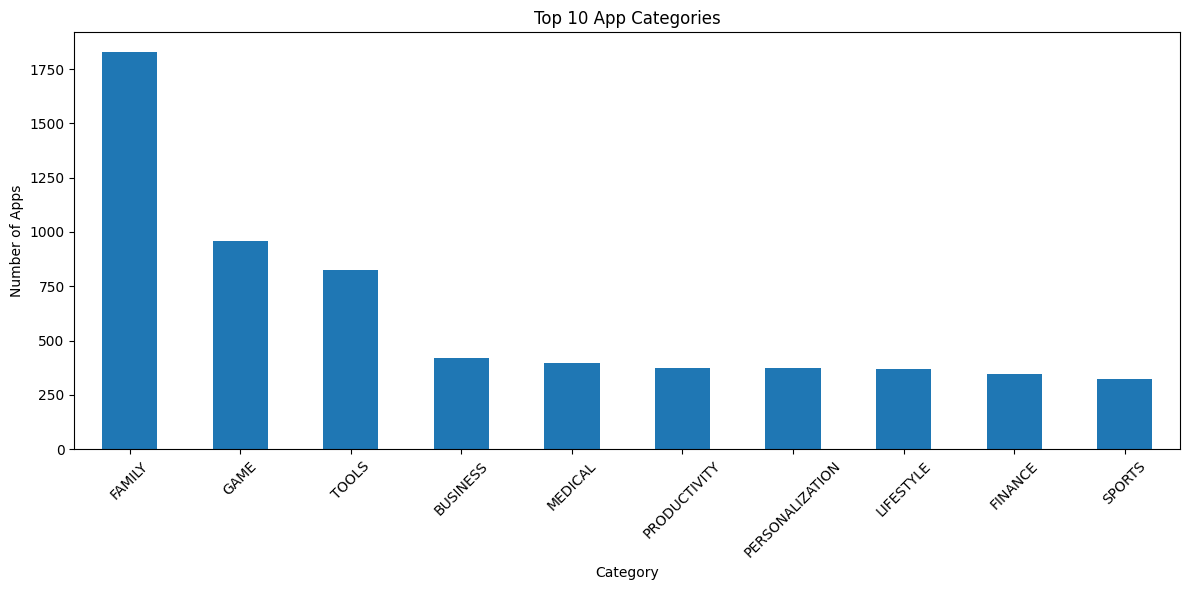

In [32]:
import matplotlib.pyplot as plt

top_categories = (
    apps_clean["Category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

top_categories.plot(
    kind="bar"
)

plt.title("Top 10 App Categories")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

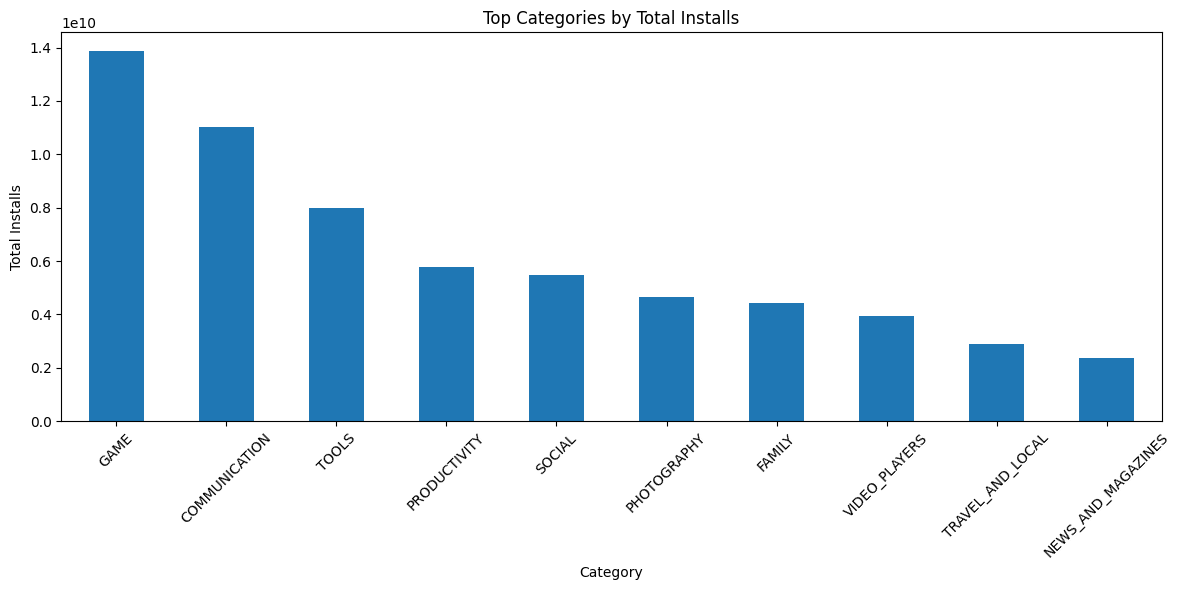

In [33]:
category_installs = (
    apps_clean
    .groupby("Category")["Installs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

category_installs.plot(
    kind="bar"
)

plt.title("Top Categories by Total Installs")
plt.xlabel("Category")
plt.ylabel("Total Installs")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_categories_installs.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
apps_clean.to_csv(
    "apps_clean_v3.csv",
    index=False
)

print("apps_clean_v3.csv Saved")

apps_clean_v3.csv Saved


In [35]:
reviews_clean["Sentiment"].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

In [36]:
print("Before:", reviews_clean.shape)

reviews_clean = reviews_clean.dropna(
    subset=["Sentiment"]
)

print("After:", reviews_clean.shape)

Before: (64295, 5)
After: (37432, 5)


In [37]:
reviews_clean.isnull().sum()

App                       0
Translated_Review         5
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64

In [38]:
review_summary = reviews_clean.groupby("App").agg(
    Avg_Sentiment_Polarity=("Sentiment_Polarity", "mean"),
    Avg_Sentiment_Subjectivity=("Sentiment_Subjectivity", "mean"),
    Review_Count=("Translated_Review", "count")
).reset_index()

review_summary.head()

,App,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Review_Count
0,10 Best Foods for You,0.470733,0.495455,194
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,0.392405,0.545516,40
2,11st,0.181294,0.443957,39
3,1800 Contacts - Lens Store,0.318145,0.591098,80
4,1LINE – One Line with One Touch,0.196290,0.557315,38


In [39]:
sentiment_counts = pd.crosstab(
    reviews_clean["App"],
    reviews_clean["Sentiment"]
)

sentiment_counts = sentiment_counts.reset_index()

sentiment_counts.head()

Sentiment,App,Negative,Neutral,Positive
0,10 Best Foods for You,10,22,162
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31
2,11st,7,10,23
3,1800 Contacts - Lens Store,6,10,64
4,1LINE – One Line with One Touch,8,3,27


In [40]:
print(sentiment_counts.columns)

Index(['App', 'Negative', 'Neutral', 'Positive'], dtype='object', name='Sentiment')


In [41]:
review_summary.to_csv(
    "review_summary.csv",
    index=False
)

sentiment_counts.to_csv(
    "sentiment_counts.csv",
    index=False
)

print("Files Saved")

Files Saved


In [42]:
sentiment_counts["Total_Reviews"] = (
    sentiment_counts["Negative"] +
    sentiment_counts["Neutral"] +
    sentiment_counts["Positive"]
)

sentiment_counts.head()

Sentiment,App,Negative,Neutral,Positive,Total_Reviews
0,10 Best Foods for You,10,22,162,194
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31,40
2,11st,7,10,23,40
3,1800 Contacts - Lens Store,6,10,64,80
4,1LINE – One Line with One Touch,8,3,27,38


In [43]:
sentiment_counts["Positive_Percent"] = (
    sentiment_counts["Positive"]
    / sentiment_counts["Total_Reviews"]
) * 100

sentiment_counts["Negative_Percent"] = (
    sentiment_counts["Negative"]
    / sentiment_counts["Total_Reviews"]
) * 100

sentiment_counts["Neutral_Percent"] = (
    sentiment_counts["Neutral"]
    / sentiment_counts["Total_Reviews"]
) * 100

sentiment_counts.head()

Sentiment,App,Negative,Neutral,Positive,Total_Reviews,Positive_Percent,Negative_Percent,Neutral_Percent
0,10 Best Foods for You,10,22,162,194,83.505155,5.154639,11.340206
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31,40,77.500000,2.500000,20.000000
2,11st,7,10,23,40,57.500000,17.500000,25.000000
3,1800 Contacts - Lens Store,6,10,64,80,80.000000,7.500000,12.500000
4,1LINE – One Line with One Touch,8,3,27,38,71.052632,21.052632,7.894737


In [44]:
final_df = apps_clean.merge(
    review_summary,
    on="App",
    how="left"
)

print(final_df.shape)

(9648, 17)


In [45]:
final_df = final_df.merge(
    sentiment_counts,
    on="App",
    how="left"
)

print(final_df.shape)

(9648, 24)


In [46]:
review_cols = [
    "Avg_Sentiment_Polarity",
    "Avg_Sentiment_Subjectivity",
    "Review_Count",
    "Positive",
    "Negative",
    "Neutral",
    "Total_Reviews",
    "Positive_Percent",
    "Negative_Percent",
    "Neutral_Percent"
]

final_df[review_cols] = (
    final_df[review_cols]
    .fillna(0)
)

final_df[review_cols].isnull().sum()

Avg_Sentiment_Polarity        0
Avg_Sentiment_Subjectivity    0
Review_Count                  0
Positive                      0
Negative                      0
Neutral                       0
Total_Reviews                 0
Positive_Percent              0
Negative_Percent              0
Neutral_Percent               0
dtype: int64

In [47]:
final_df.to_csv(
    "google_playstore_final_dataset.csv",
    index=False
)

print(final_df.shape)
print("Final Dataset Saved")

(9648, 24)
Final Dataset Saved


In [52]:
ml_df = final_df[[
    "Category",
    "Reviews",
    "Installs",
    "Price",
    "Size_KB",
    "Avg_Sentiment_Polarity",
    "Avg_Sentiment_Subjectivity",
    "Review_Count",
    "Positive_Percent",
    "Negative_Percent",
    "Rating"
]].copy()

ml_df.head()

,Category,Reviews,Installs,Price,Size_KB,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Review_Count,Positive_Percent,Negative_Percent,Rating
0,ART_AND_DESIGN,159.0,10000.0,0.0,19456.0,0.000000,0.00000,0.0,0.000000,0.000000,4.1
1,ART_AND_DESIGN,967.0,500000.0,0.0,14336.0,0.152652,0.64154,44.0,59.090909,31.818182,3.9
2,ART_AND_DESIGN,87510.0,5000000.0,0.0,8908.8,0.000000,0.00000,0.0,0.000000,0.000000,4.7
3,ART_AND_DESIGN,215644.0,50000000.0,0.0,25600.0,0.000000,0.00000,0.0,0.000000,0.000000,4.5
4,ART_AND_DESIGN,967.0,100000.0,0.0,2867.2,0.000000,0.00000,0.0,0.000000,0.000000,4.3


In [53]:
ml_df.isnull().sum()

Category                      0
Reviews                       0
Installs                      0
Price                         0
Size_KB                       0
Avg_Sentiment_Polarity        0
Avg_Sentiment_Subjectivity    0
Review_Count                  0
Positive_Percent              0
Negative_Percent              0
Rating                        0
dtype: int64

In [54]:
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()

ml_df["Category"] = le_category.fit_transform(
    ml_df["Category"]
)

ml_df.head()

,Category,Reviews,Installs,Price,Size_KB,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Review_Count,Positive_Percent,Negative_Percent,Rating
0,0,159.0,10000.0,0.0,19456.0,0.000000,0.00000,0.0,0.000000,0.000000,4.1
1,0,967.0,500000.0,0.0,14336.0,0.152652,0.64154,44.0,59.090909,31.818182,3.9
2,0,87510.0,5000000.0,0.0,8908.8,0.000000,0.00000,0.0,0.000000,0.000000,4.7
3,0,215644.0,50000000.0,0.0,25600.0,0.000000,0.00000,0.0,0.000000,0.000000,4.5
4,0,967.0,100000.0,0.0,2867.2,0.000000,0.00000,0.0,0.000000,0.000000,4.3


In [51]:
X = ml_df.drop("Rating", axis=1)

y = ml_df["Rating"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (9648, 10)
Target Shape: (9648,)


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X Train:", X_train.shape)
print("X Test :", X_test.shape)

X Train: (7718, 10)
X Test : (1930, 10)


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [57]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

[4.573 4.345 4.083 4.165 4.381 4.004 4.11  4.263 3.973 4.082]


In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

MAE : 0.32024300024673086
MSE : 0.22989609313949103
R2  : 0.038365281834718656


In [59]:
import joblib

joblib.dump(
    rf_model,
    "playstore_rating_model.pkl"
)

print("Model Saved")

Model Saved


In [60]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Reviews,0.353102
4,Size_KB,0.311050
0,Category,0.169438
2,Installs,0.113847
3,Price,0.032773
5,Avg_Sentiment_Polarity,0.005670
8,Positive_Percent,0.003886
7,Review_Count,0.003590
6,Avg_Sentiment_Subjectivity,0.003346
9,Negative_Percent,0.003298


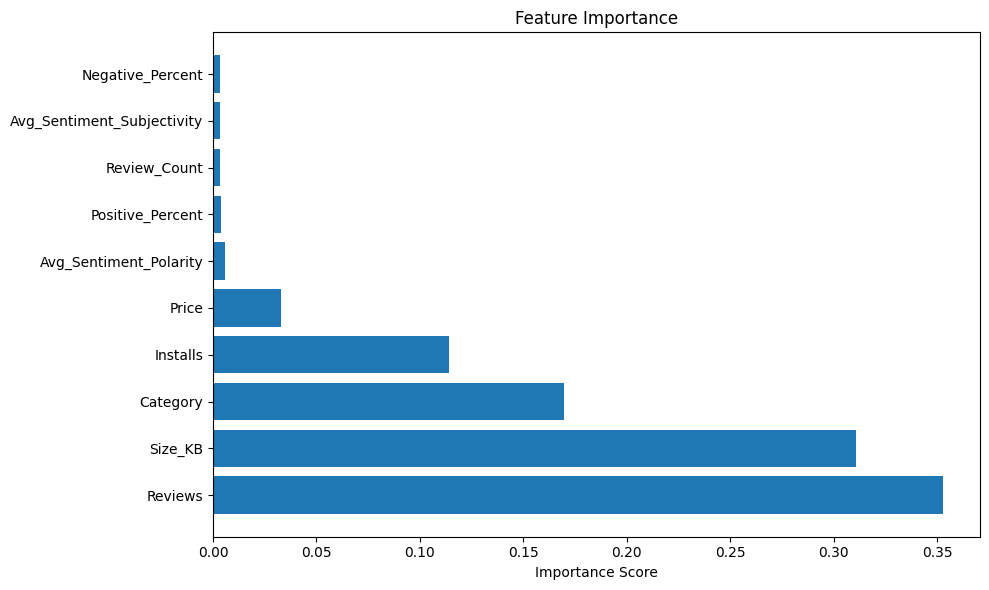

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.tight_layout()

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
feature_importance.head(10)

,Feature,Importance
1,Reviews,0.353102
4,Size_KB,0.311050
0,Category,0.169438
2,Installs,0.113847
3,Price,0.032773
5,Avg_Sentiment_Polarity,0.005670
8,Positive_Percent,0.003886
7,Review_Count,0.003590
6,Avg_Sentiment_Subjectivity,0.003346
9,Negative_Percent,0.003298


In [63]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Saved")

Saved


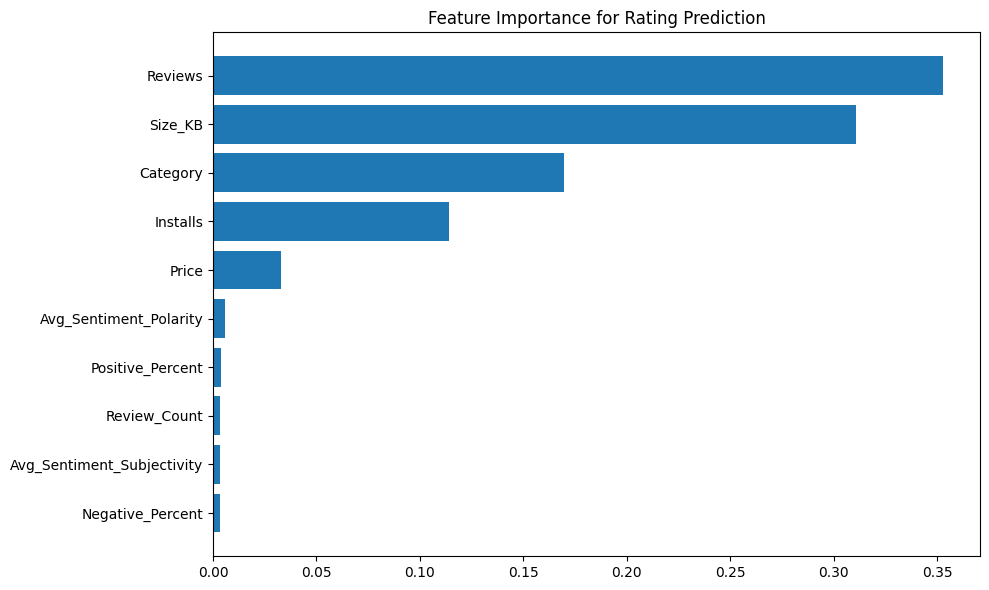

In [64]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance for Rating Prediction")

plt.tight_layout()

plt.savefig(
    "feature_importance_rating_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

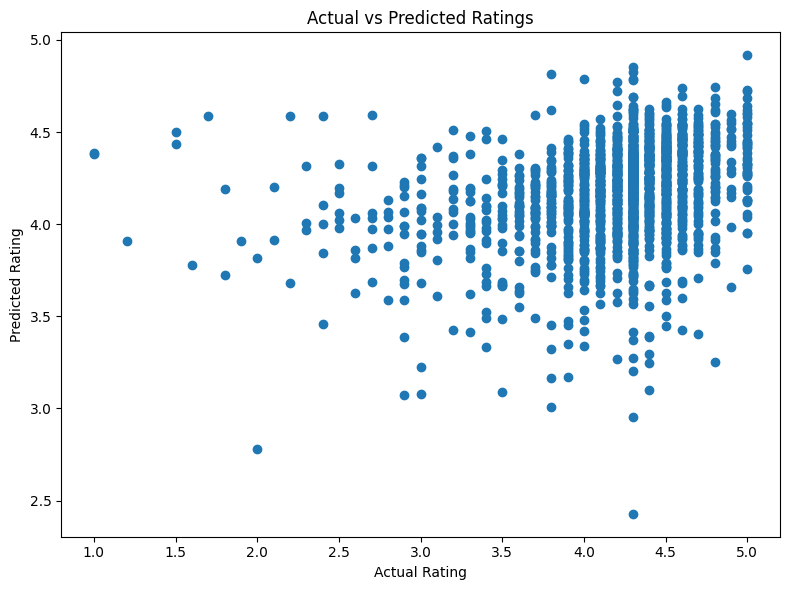

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
import joblib

joblib.dump(
    le_category,
    "category_encoder.pkl"
)

print("Encoder Saved")

Encoder Saved


In [67]:
classification_df = final_df.copy()

classification_df["Popular_App"] = (
    classification_df["Installs"] >= 1000000
).astype(int)

classification_df["Popular_App"].value_counts()

Popular_App
0    6254
1    3394
Name: count, dtype: int64

In [68]:
clf_df = classification_df[[
    "Category",
    "Reviews",
    "Price",
    "Size_KB",
    "Avg_Sentiment_Polarity",
    "Avg_Sentiment_Subjectivity",
    "Review_Count",
    "Positive_Percent",
    "Negative_Percent",
    "Popular_App"
]].copy()

clf_df.head()

,Category,Reviews,Price,Size_KB,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Review_Count,Positive_Percent,Negative_Percent,Popular_App
0,ART_AND_DESIGN,159.0,0.0,19456.0,0.000000,0.00000,0.0,0.000000,0.000000,0
1,ART_AND_DESIGN,967.0,0.0,14336.0,0.152652,0.64154,44.0,59.090909,31.818182,0
2,ART_AND_DESIGN,87510.0,0.0,8908.8,0.000000,0.00000,0.0,0.000000,0.000000,1
3,ART_AND_DESIGN,215644.0,0.0,25600.0,0.000000,0.00000,0.0,0.000000,0.000000,1
4,ART_AND_DESIGN,967.0,0.0,2867.2,0.000000,0.00000,0.0,0.000000,0.000000,0


In [69]:
from sklearn.preprocessing import LabelEncoder

clf_encoder = LabelEncoder()

clf_df["Category"] = clf_encoder.fit_transform(
    clf_df["Category"]
)

clf_df.head()

,Category,Reviews,Price,Size_KB,Avg_Sentiment_Polarity,Avg_Sentiment_Subjectivity,Review_Count,Positive_Percent,Negative_Percent,Popular_App
0,0,159.0,0.0,19456.0,0.000000,0.00000,0.0,0.000000,0.000000,0
1,0,967.0,0.0,14336.0,0.152652,0.64154,44.0,59.090909,31.818182,0
2,0,87510.0,0.0,8908.8,0.000000,0.00000,0.0,0.000000,0.000000,1
3,0,215644.0,0.0,25600.0,0.000000,0.00000,0.0,0.000000,0.000000,1
4,0,967.0,0.0,2867.2,0.000000,0.00000,0.0,0.000000,0.000000,0


In [70]:
X_clf = clf_df.drop(
    "Popular_App",
    axis=1
)

y_clf = clf_df["Popular_App"]

print("X Shape:", X_clf.shape)
print("Y Shape:", y_clf.shape)

print("\nClass Distribution")
print(y_clf.value_counts())

X Shape: (9648, 9)
Y Shape: (9648,)

Class Distribution
Popular_App
0    6254
1    3394
Name: count, dtype: int64


In [71]:
from sklearn.model_selection import train_test_split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Train:", X_train_clf.shape)
print("Test :", X_test_clf.shape)

Train: (7718, 9)
Test : (1930, 9)


In [72]:
from sklearn.ensemble import RandomForestClassifier

popular_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

popular_model.fit(
    X_train_clf,
    y_train_clf
)

print("Popular App Model Trained")

Popular App Model Trained


In [73]:
y_pred_clf = popular_model.predict(
    X_test_clf
)

print(y_pred_clf[:20])

[0 0 1 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1]


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test_clf,
    y_pred_clf
)

precision = precision_score(
    y_test_clf,
    y_pred_clf
)

recall = recall_score(
    y_test_clf,
    y_pred_clf
)

f1 = f1_score(
    y_test_clf,
    y_pred_clf
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9471502590673575
Precision: 0.9312406576980568
Recall   : 0.9175257731958762
F1 Score : 0.9243323442136498


In [75]:
import joblib

joblib.dump(
    popular_model,
    "popular_app_model.pkl"
)

joblib.dump(
    clf_encoder,
    "popular_app_encoder.pkl"
)

print("Popular App Model Saved")

Popular App Model Saved


In [76]:
print(X.columns.tolist())
print(X_clf.columns.tolist())

['Category', 'Reviews', 'Installs', 'Price', 'Size_KB', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity', 'Review_Count', 'Positive_Percent', 'Negative_Percent']
['Category', 'Reviews', 'Price', 'Size_KB', 'Avg_Sentiment_Polarity', 'Avg_Sentiment_Subjectivity', 'Review_Count', 'Positive_Percent', 'Negative_Percent']


In [77]:
print(
    final_df[
        [
            "Positive_Percent",
            "Negative_Percent",
            "Neutral_Percent"
        ]
    ].head()
)

   Positive_Percent  Negative_Percent  Neutral_Percent
0          0.000000          0.000000         0.000000
1         59.090909         31.818182         9.090909
2          0.000000          0.000000         0.000000
3          0.000000          0.000000         0.000000
4          0.000000          0.000000         0.000000


In [78]:
print(
    final_df[
        [
            "Positive_Percent",
            "Negative_Percent",
            "Neutral_Percent"
        ]
    ].describe()
)

       Positive_Percent  Negative_Percent  Neutral_Percent
count       9648.000000       9648.000000      9648.000000
mean           5.472663          1.728038         1.257010
std           18.774680          7.425822         5.592562
min            0.000000          0.000000         0.000000
25%            0.000000          0.000000         0.000000
50%            0.000000          0.000000         0.000000
75%            0.000000          0.000000         0.000000
max          100.000000        100.000000       100.000000


In [79]:
df = pd.read_csv(
    "google_playstore_final_dataset.csv"
)

print(df.columns)

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_KB', 'Avg_Sentiment_Polarity',
       'Avg_Sentiment_Subjectivity', 'Review_Count', 'Negative', 'Neutral',
       'Positive', 'Total_Reviews', 'Positive_Percent', 'Negative_Percent',
       'Neutral_Percent'],
      dtype='object')
